In [5]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

G = nx.read_edgelist("facebook_combined.txt")

In [6]:
# Notions of centrality

deg_cent = nx.degree_centrality(G)
bet_cent = nx.betweenness_centrality(G)
eig_cent = nx.eigenvector_centrality(G, max_iter=1000)

# Top 5 nodes
top_deg = sorted(deg_cent.items(), key=lambda x: x[1], reverse=True)[:5]
top_bet = sorted(bet_cent.items(), key=lambda x: x[1], reverse=True)[:5]
top_eig = sorted(eig_cent.items(), key=lambda x: x[1], reverse=True)[:5]

In [46]:
degrees = [d for n, d in G.degree()]
np.std(degrees)

52.41411556737521

In [17]:
print("Top 5 degrees:", top_deg)
print("Top 5 betweenness:", top_bet)
print("Top 5 eigenvector centrality:", top_eig)

Top 5 degrees: [('107', 0.258791480931154), ('1684', 0.1961367013372957), ('1912', 0.18697374938088163), ('3437', 0.13546310054482416), ('0', 0.08593363051015354)]
Top 5 betweenness: [('107', 0.4805180785560152), ('1684', 0.3377974497301992), ('3437', 0.23611535735892905), ('1912', 0.2292953395868782), ('1085', 0.14901509211665306)]
Top 5 eigenvector centrality: [('1912', 0.09540696149067629), ('2266', 0.08698327767886552), ('2206', 0.08605239270584342), ('2233', 0.08517340912756598), ('2464', 0.08427877475676092)]


In [7]:
# Overlap between top 10% nodes in degree and betweenness centrality

n = len(G.nodes())
k = int(0.1 * n)

top_deg_nodes = set([x[0] for x in sorted(deg_cent.items(), key=lambda x: x[1], reverse=True)[:k]])
top_bet_nodes = set([x[0] for x in sorted(bet_cent.items(), key=lambda x: x[1], reverse=True)[:k]])

overlap = len(top_deg_nodes & top_bet_nodes)
print("Overlap:", overlap)

Overlap: 105


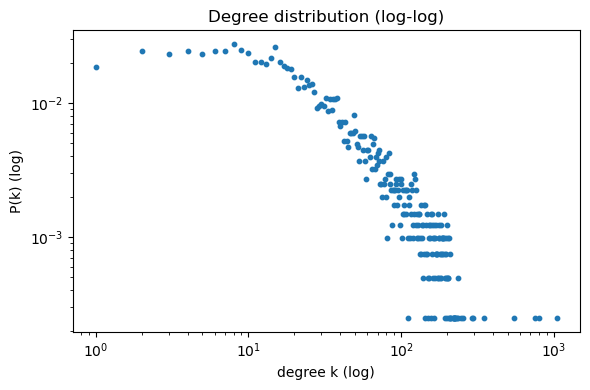

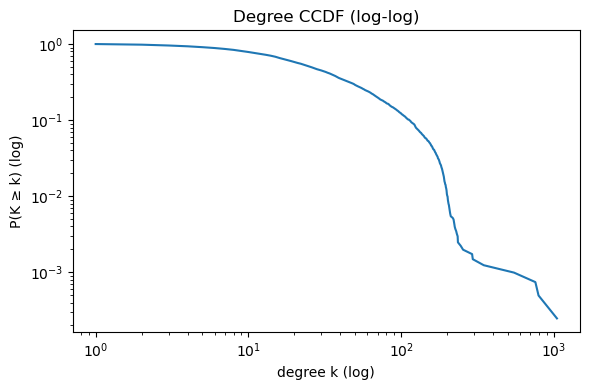

In [55]:
# Degree distribution
degrees = np.array([d for _, d in G.degree()])
max_k = degrees.max()

# PDF
cnt = Counter(degrees)
ks = np.array(sorted(cnt.keys()))
pk = np.array([cnt[k] for k in ks]) / len(degrees)

plt.figure(figsize=(6,4))
plt.scatter(ks, pk, s=10)
plt.xscale("log"); plt.yscale("log")
plt.xlabel("degree k (log)")
plt.ylabel("P(k) (log)")
plt.title("Degree distribution (log-log)")
plt.tight_layout()
plt.show()

# CCDF: P(K >= k)
ks_sorted = np.sort(degrees)
ccdf_x = np.unique(ks_sorted)
ccdf_y = np.array([(ks_sorted >= k).mean() for k in ccdf_x])

plt.figure(figsize=(6,4))
plt.plot(ccdf_x, ccdf_y)
plt.xscale("log"); plt.yscale("log")
plt.xlabel("degree k (log)")
plt.ylabel("P(K ≥ k) (log)")
plt.title("Degree CCDF (log-log)")
plt.tight_layout()
plt.show()


Community Detection

In [8]:
#Louvain community detection (Unbounded)
import community as community_louvain
partition = community_louvain.best_partition(G)

In [9]:
num_communities = len(set(partition.values()))
print("Louvain communities:", num_communities)
modularity = community_louvain.modularity(partition, G)
print("Modularity:", modularity)

Louvain communities: 16
Modularity: 0.8347010356608258


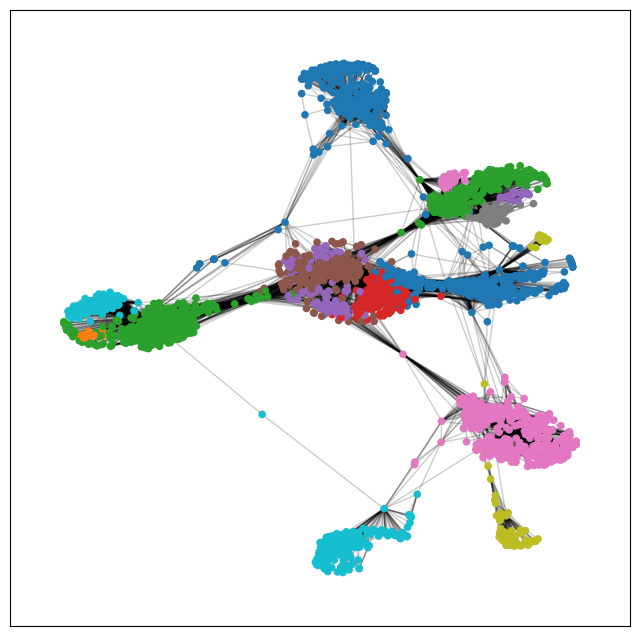

In [10]:
# Largest connected component
Gcc = G.subgraph(max(nx.connected_components(G), key=len))
pos = nx.spring_layout(Gcc, seed=42)

partition_c = community_louvain.best_partition(Gcc)

colors = [partition_c[node] for node in Gcc.nodes()]

plt.figure(figsize=(8,8))
nx.draw_networkx_nodes(Gcc, pos, node_color=colors, cmap=plt.cm.tab10, node_size=20)
nx.draw_networkx_edges(Gcc, pos, alpha=0.2)
plt.show()

In [49]:
from collections import Counter

max(Counter(partition.values()).values())

548

In [11]:
#Greedy modularity communities (Unbounded)
from networkx.algorithms.community import greedy_modularity_communities

communities = list(greedy_modularity_communities(G))
print("Greedy communities:", len(communities))

Greedy communities: 16


In [12]:
modularity_greedy = nx.algorithms.community.modularity(G, communities)
print("Greedy modularity:", modularity_greedy)

Greedy modularity: 0.7745287500467251


In [13]:
# Spectral clustering (Bounded)
from sklearn.cluster import SpectralClustering

A = nx.to_numpy_array(G)

sc = SpectralClustering(n_clusters=5, affinity='precomputed')
labels = sc.fit_predict(A)

print("Fixed k = 16 communities")

Fixed k = 16 communities


In [14]:
#Spectral clustering + K-means (Bounded)
from sklearn.cluster import KMeans
from scipy.sparse.linalg import eigsh

# Compute normalized Laplacian
L = nx.normalized_laplacian_matrix(Gcc)

c:\Users\19666\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


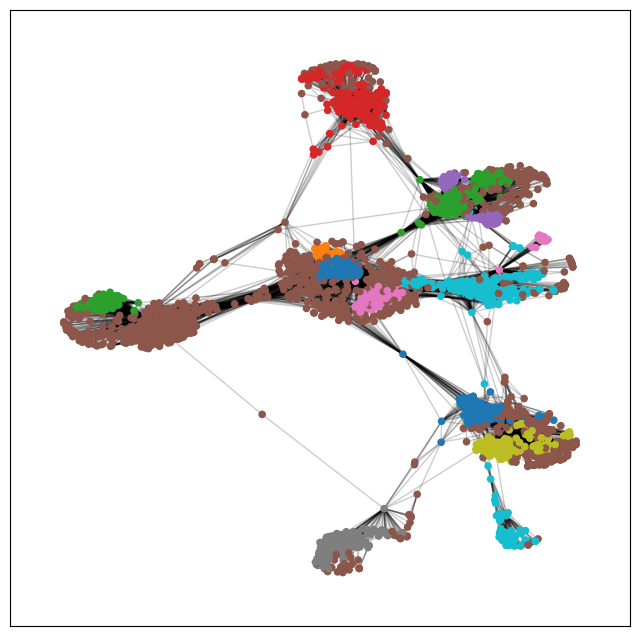

In [15]:
k = 16 # Number of clusters to partition into

eigenvalues, eigenvectors = eigsh(L, k=k, which='SM')

kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(eigenvectors)

node_list = list(Gcc.nodes())
community_map = {node_list[i]: labels[i] for i in range(len(node_list))}

colors = [community_map[node] for node in Gcc.nodes()]

plt.figure(figsize=(8,8))
nx.draw_networkx_nodes(Gcc, pos, node_color=colors, cmap=plt.cm.tab10, node_size=20)
nx.draw_networkx_edges(Gcc, pos, alpha=0.2)
plt.show()

Community Analysis

In [16]:
from collections import defaultdict

communities = defaultdict(list)

for node, comm in partition_c.items():
    communities[comm].append(node)

# Sort communities by size
sorted_comms = sorted(communities.items(), key=lambda x: len(x[1]), reverse=True)

# Largest community
largest_comm_id, largest_nodes = sorted_comms[0]

print("Largest community size:", len(largest_nodes))

Largest community size: 548


In [17]:
# Get degrees restricted to largest community
subG = Gcc.subgraph(largest_nodes)

top5 = sorted(subG.degree(), key=lambda x: x[1], reverse=True)[:5]
print(top5)

[('3437', 545), ('3830', 108), ('3596', 86), ('3938', 83), ('3545', 83)]


In [18]:
nx.density(subG)

0.03573573172847249

In [19]:
nx.average_clustering(subG)

0.624584047933371

In [20]:
internal_edges = subG.number_of_edges()

cut_edges = 0
for node in largest_nodes:
    for neighbor in Gcc.neighbors(node):
        if neighbor not in largest_nodes:
            cut_edges += 1

print("Internal edges:", internal_edges)
print("External edges:", cut_edges)

Internal edges: 5356
External edges: 45


In [11]:
nx.write_gexf(G, "facebook.gexf")

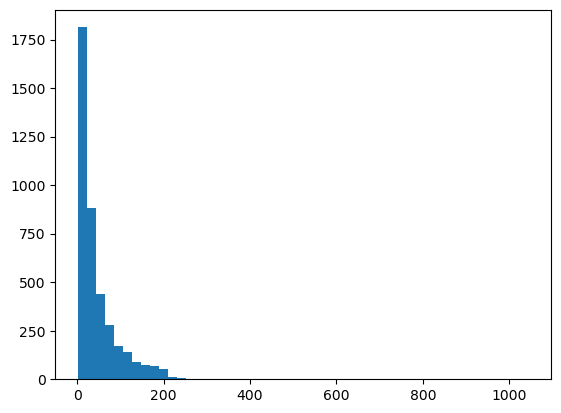

In [21]:
import matplotlib.pyplot as plt
import collections

degrees = [d for n, d in G.degree()]
plt.hist(degrees, bins=50)
plt.show()

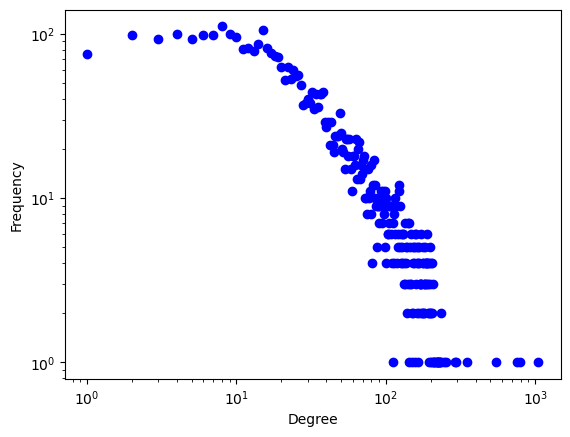

In [22]:
degree_count = collections.Counter(degrees)
deg, cnt = zip(*degree_count.items())

plt.loglog(deg, cnt, 'bo')
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.show()

In [23]:
# Diameter and average shortest path length

print("Diameter:", nx.diameter(G))
print("Average shortest path:", nx.average_shortest_path_length(G))

Diameter: 8
Average shortest path: 3.6925068496963913


Comparison to Barabasi-Albert, Watts-Strogatz and Erd¨os-Renyi graphs

In [24]:
#Watts-Strogatz small-world model
n = Gcc.number_of_nodes()
avg_degree = sum(dict(Gcc.degree()).values()) / n

k = int(avg_degree)  # nearest even number
p = 0.1              # typical small-world rewiring

WS = nx.watts_strogatz_graph(n, k, p)

In [25]:
sum(dict(WS.degree()).values()) / n

42.0

In [26]:
print("Facebook clustering:", nx.average_clustering(Gcc))
print("WS clustering:", nx.average_clustering(WS))

print("Facebook avg path:", nx.average_shortest_path_length(Gcc))
print("WS avg path:", nx.average_shortest_path_length(WS))

Facebook clustering: 0.6055467186200876
WS clustering: 0.5357599055071885
Facebook avg path: 3.6925068496963913
WS avg path: 3.005852055877679


In [27]:
#Barabási-Albert preferential attachment model
m_real = Gcc.number_of_edges() 
print("Nodes:", n)
print("Edges:", m_real)
print("Avg degree:", avg_degree)

m = int(avg_degree / 2)
BA = nx.barabasi_albert_graph(n, m)

Nodes: 4039
Edges: 88234
Avg degree: 43.69101262688784


In [28]:
# Erdos-Rényi random graph
p = (2 * m_real) / (n * (n - 1))
ER = nx.erdos_renyi_graph(n, p)

In [29]:
def graph_stats(G):
    return {
        "avg_clustering": nx.average_clustering(G),
        "avg_path_length": nx.average_shortest_path_length(G),
        "diameter": nx.diameter(G),
        "density": nx.density(G)
    }

print("Facebook:", graph_stats(Gcc))
print("BA:", graph_stats(BA))
print("ER:", graph_stats(ER))
print("WS:", graph_stats(WS))

Facebook: {'avg_clustering': 0.6055467186200876, 'avg_path_length': 3.6925068496963913, 'diameter': 8, 'density': 0.010819963503439287}
BA: {'avg_clustering': 0.035810639585816297, 'avg_path_length': 2.5375197078607403, 'diameter': 4, 'density': 0.010347109736532405}
ER: {'avg_clustering': 0.01092830240017009, 'avg_path_length': 2.6044568429579797, 'diameter': 4, 'density': 0.010846451162581374}
WS: {'avg_clustering': 0.5357599055071885, 'avg_path_length': 3.005852055877679, 'diameter': 4, 'density': 0.010401188707280832}


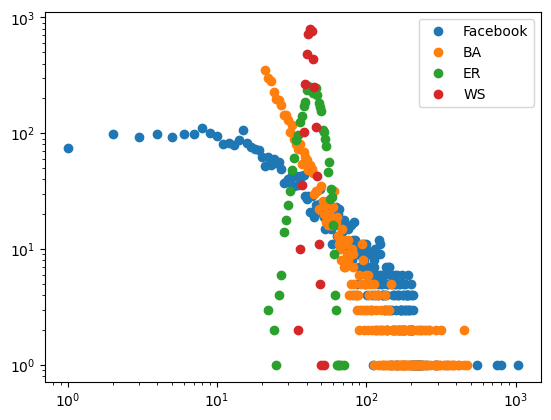

In [30]:
def plot_degree_distribution(G, label):
    degrees = [d for n, d in G.degree()]
    degree_count = collections.Counter(degrees)
    deg, cnt = zip(*sorted(degree_count.items()))
    plt.loglog(deg, cnt, marker='o', linestyle='', label=label)

plt.figure()
plot_degree_distribution(Gcc, "Facebook")
plot_degree_distribution(BA, "BA")
plot_degree_distribution(ER, "ER")
plot_degree_distribution(WS, "WS")
plt.legend()
plt.show()

In [31]:
partition_ba = community_louvain.best_partition(BA)
partition_er = community_louvain.best_partition(ER)
partition_ws = community_louvain.best_partition(WS)

print("BA communities:", len(set(partition_ba.values())))
print("ER communities:", len(set(partition_er.values())))
print("WS communities:", len(set(partition_ws.values())))

BA communities: 8
ER communities: 9
WS communities: 20


Requested part

In [32]:
nx.degree_assortativity_coefficient(G)

0.06357722918564943

In [36]:
# Take LCCs for path metrics
def lcc(G):
    return G.subgraph(max(nx.connected_components(G), key=len)).copy()

G_s_lcc = lcc(G)
models = {
    "Facebook": G_s_lcc,
    "ER": lcc(ER),
    "BA": lcc(BA),
    "WS": lcc(WS),
}
{k: (v.number_of_nodes(), v.number_of_edges()) for k,v in models.items()}

{'Facebook': (4039, 88234),
 'ER': (4039, 88450),
 'BA': (4039, 84378),
 'WS': (4039, 84819)}

In [37]:
from networkx.algorithms.approximation import diameter as approx_diameter
import pandas as pd

def approx_average_shortest_path_length(G: nx.Graph, sample_size: int = 200, seed: int = 42) -> float:
    rng = np.random.default_rng(seed)
    nodes = list(G.nodes())
    sample = rng.choice(nodes, size=min(sample_size, len(nodes)), replace=False)
    dists = []
    for s in sample:
        lengths = nx.single_source_shortest_path_length(G, s)
        dists.extend([d for t,d in lengths.items() if t != s])
    return float(np.mean(dists)) if dists else float('nan')

def graph_metrics(G: nx.Graph) -> dict:
    n, m = G.number_of_nodes(), G.number_of_edges()
    avg_deg = 2*m/n if n else float('nan')
    clust = nx.average_clustering(G) if n else float('nan')
    apl = approx_average_shortest_path_length(G, sample_size=200, seed=42) if n else float('nan')
    diam = approx_diameter(G) if n else float('nan')
    assort = nx.degree_assortativity_coefficient(G) if m > 0 else float('nan')
    return {"n": n, "m": m, "avg_degree": avg_deg, "clustering": clust, "avg_path_approx": apl, "diam_approx": diam, "assortativity": assort}

metrics_df = pd.DataFrame({name: graph_metrics(g) for name,g in models.items()}).T
metrics_df


,n,m,avg_degree,clustering,avg_path_approx,diam_approx,assortativity
Facebook,4039.0,88234.0,43.691013,0.605547,3.714631,8.0,0.063577
ER,4039.0,88450.0,43.797970,0.010928,2.601634,3.0,-0.001497
BA,4039.0,84378.0,41.781629,0.035811,2.545727,3.0,-0.007219
WS,4039.0,84819.0,42.000000,0.535760,3.002961,4.0,-0.005796


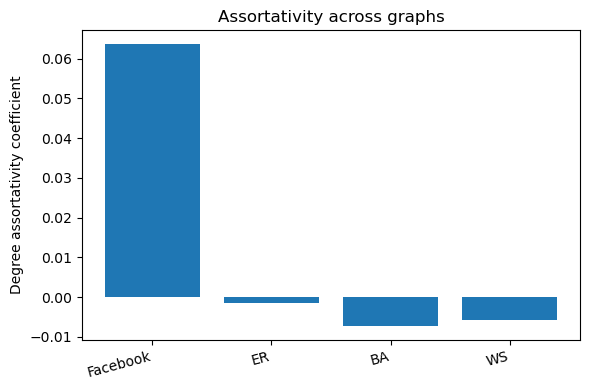

In [38]:
# 9.1 Assortativity (bar)
plt.figure(figsize=(6,4))
plt.bar(metrics_df.index, metrics_df["assortativity"].values)
plt.ylabel("Degree assortativity coefficient")
plt.title("Assortativity across graphs")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()


In [39]:
# 9.2 Small-world coefficient (Humphries & Gurney style heuristic)
# sigma = (C/Crand) / (L/Lrand)
# We approximate L with sampled BFS distances (fast).
def small_world_sigma(G: nx.Graph, G_rand: nx.Graph) -> float:
    C = nx.average_clustering(G)
    L = approx_average_shortest_path_length(G, sample_size=200, seed=42)
    Cr = nx.average_clustering(G_rand)
    Lr = approx_average_shortest_path_length(G_rand, sample_size=200, seed=42)
    return (C/Cr) / (L/Lr)

sigma = {}
for name, g in models.items():
    n = g.number_of_nodes()
    m = g.number_of_edges()
    avg_deg = 2*m/n
    p = avg_deg/(n-1)
    g_er_base = lcc(nx.erdos_renyi_graph(n, p, seed=123))
    sigma[name] = small_world_sigma(g, g_er_base)

sigma_df = pd.DataFrame.from_dict(sigma, orient="index", columns=["small_world_sigma"])
sigma_df


,small_world_sigma
Facebook,39.036253
ER,1.002592
BA,3.557880
WS,44.837352


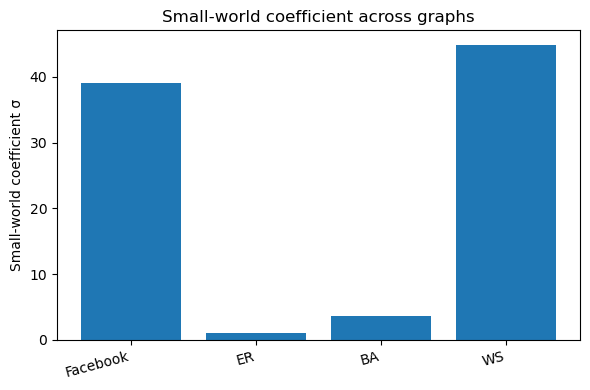

In [40]:
plt.figure(figsize=(6,4))
plt.bar(sigma_df.index, sigma_df["small_world_sigma"].values)
plt.ylabel("Small-world coefficient σ")
plt.title("Small-world coefficient across graphs")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()


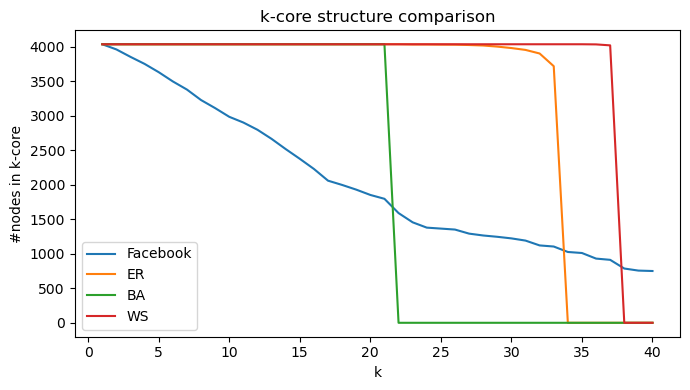

In [41]:
# 9.3 k-core structure curves
def kcore_curve(G: nx.Graph, k_max: int = 40):
    sizes = []
    for k in range(1, k_max+1):
        kc = nx.k_core(G, k=k)
        sizes.append(kc.number_of_nodes())
    return np.arange(1, k_max+1), np.array(sizes)

plt.figure(figsize=(7,4))
for name, g in models.items():
    ks, sizes = kcore_curve(g, k_max=40)
    plt.plot(ks, sizes, label=name)
plt.xlabel("k")
plt.ylabel("#nodes in k-core")
plt.title("k-core structure comparison")
plt.legend()
plt.tight_layout()
plt.show()


In [54]:
core_numbers = nx.core_number(G_s_lcc)
kmax = max(core_numbers.values())
print("Maximum k-core value:", kmax)
kmax_nodes = [node for node, k in core_numbers.items() if k == kmax]

print("Number of nodes in kmax-core:", len(kmax_nodes))




Maximum k-core value: 115
Number of nodes in kmax-core: 158
